**Laboratorio 1: Predecir el precio medio de las viviendas en Bostos**
Se utilizará la información de 506 suburbios de Boston, el cual se encuentra en el archivo de Excel Boston.xlsx, el cual contiene las siguientes variables explicativas:
*   **crim**: tasa de criminalidad per capita por ciudad.
*   **zn:** proporción de terreno residencial zonificado para lotes de más de 25,000 pies cuadrados.
*   **indus:** proporción de terreno destinado a negocios no minoristas por ciudad.
*   **chas:** variable ficticia del río Charles (=1 si el tramo limita con el rio; 0 en caso contrario).
*   **nox:** concentración de óxidos de nitrógeno (partes por cada 10 millones).
*   **rm:** número promedio de habitaciones por vivienda.
*   **age:** proporción de unidades ocupadas por sus propietarios construidas antes de 1940.
*   **dis:** media ponderada de las distancias a cinco centros de empleo en  Boston.
*   **rad:** índice de accesibilidad a autopistas radiales.
*   **tax:** tasa de impuesto a la propiedad por cada $10,000 de valor.
*   **ptratio:** ratio de alumnos por maestro en la ciudad.
*   **Istat:** porcentaje de población de bajo status.
*   **medv:** precio medio de las viviendas en miles de dólares (variable objetivo)




In [168]:
# 1. Importando librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [169]:
# 2. Ingestión de datos.
# Conexión con drive para obtener el archivo .csv
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [170]:
# Montar origen de datos a dataframe.
df_data = pd.read_excel("/content/drive/MyDrive/TIA_RL_DL_Files/Boston.xlsx")

In [171]:
# 3. Analisis exploratorio
# Comprobando formato de tipo para cada variable en dataframe
df_data.dtypes

,0
crim,float64
zn,float64
indus,float64
chas,int64
nox,float64
rm,float64
age,float64
dis,float64
rad,int64
tax,int64


In [172]:
# Convirtiendo variable 'chas' a tipo entero.
df_data['chas'] = df_data['chas'].astype(int)

In [173]:
# Repetir - Comprobando formato de tipo para cada variable en dataframe
df_data.dtypes

,0
crim,float64
zn,float64
indus,float64
chas,int64
nox,float64
rm,float64
age,float64
dis,float64
rad,int64
tax,int64


In [174]:
# Visualizar los primeros 15 registros del dataframe (conjunto de datos).
df_data.head(15)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,17.10,18.9


In [175]:
# Resumen de estadísticas para explorar y entender los contenidos del dataframe.
df_data.describe(include='all')

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [176]:
# Validar dimensiones del dataset.
df_data.shape

(506, 13)

In [177]:
# Comprobando la existencia de valores faltantes.
df_data.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [178]:
# Validar la existencia de valores NA. Se espera el resultado sea todos los valores 0.
df_data.isna().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


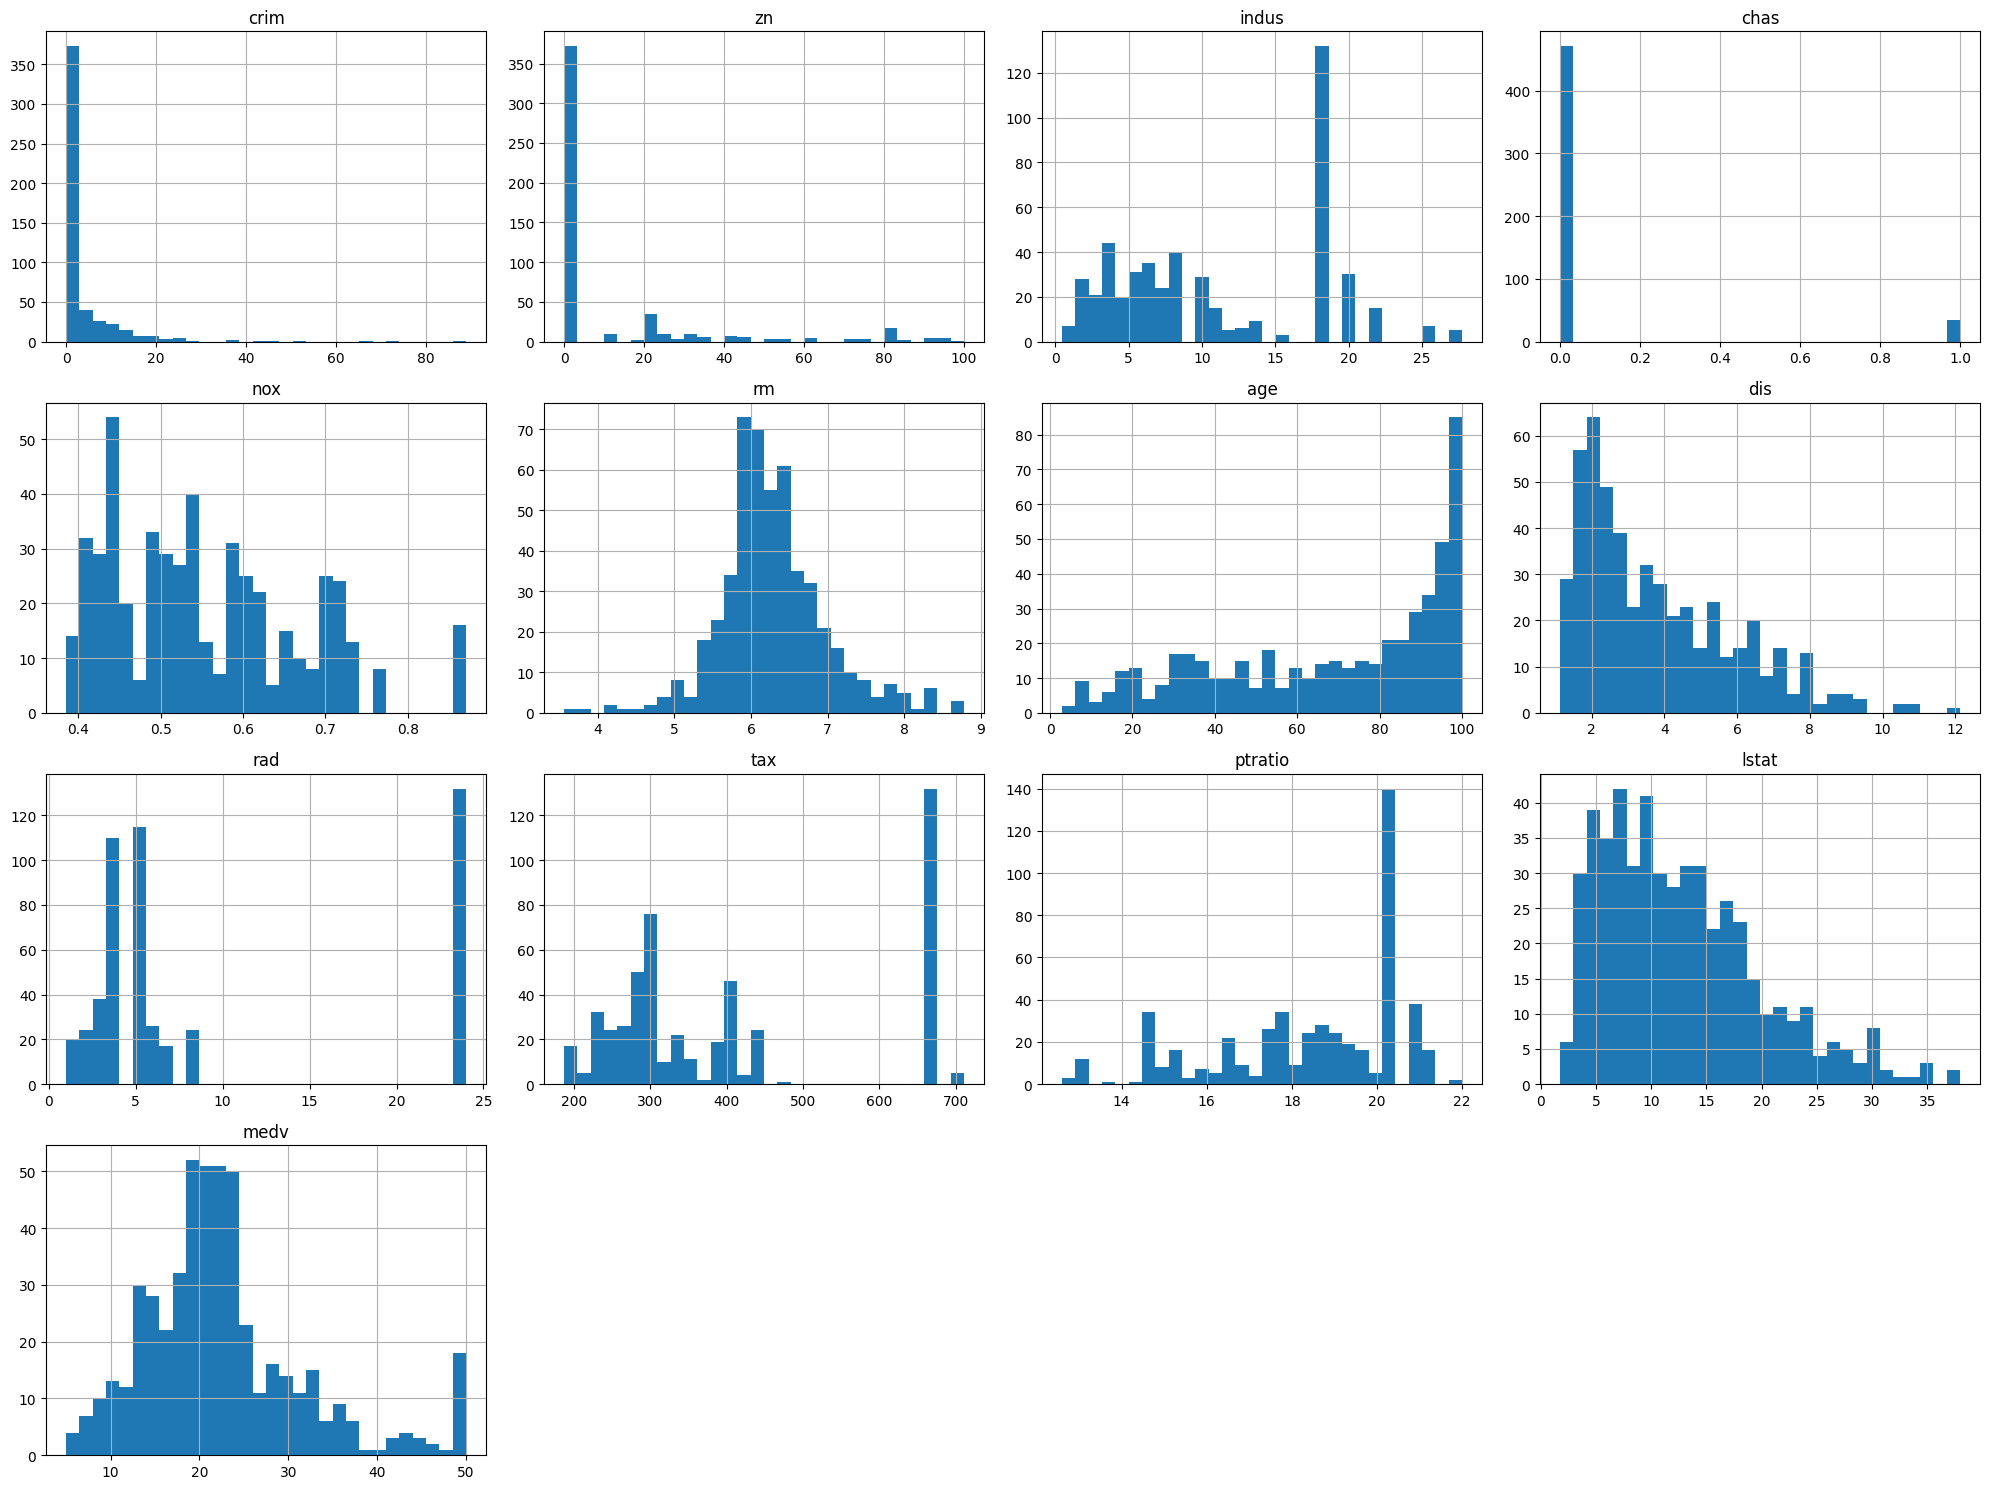

In [179]:
# Generar histogramas para cada variable
df_data.hist(bins=30, figsize=(20,15))
plt.tight_layout()
plt.show()

In [180]:
# Calculamos la matriz de correlación
correlation_matrix = df_data.corr()
correlation_matrix

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,0.543993,-0.468536


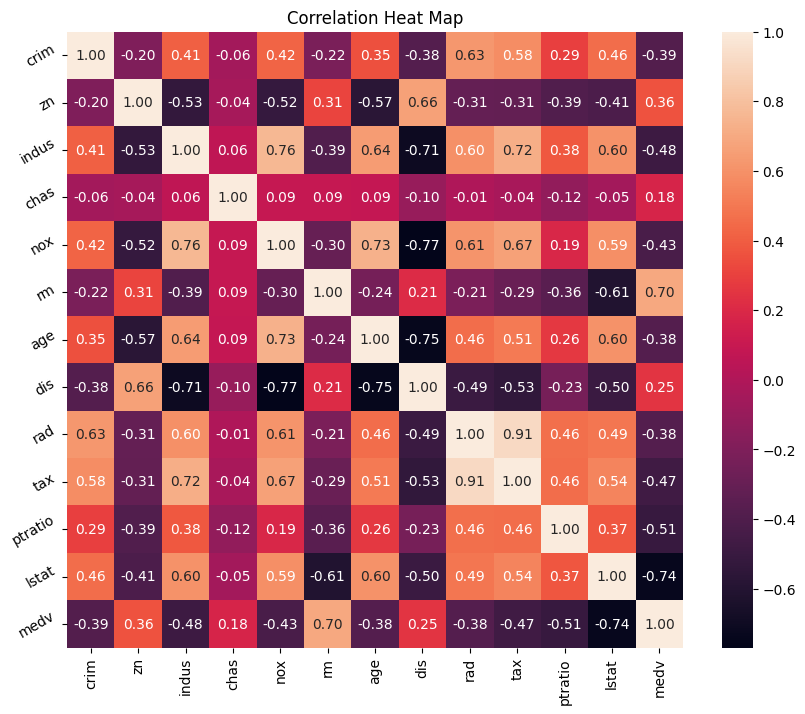

In [181]:
# Visualizar el Correlation Heat Map
import seaborn as sns
plt.figure(figsize=(10, 8))
plt.title('Correlation Heat Map')
a = sns.heatmap(correlation_matrix, square=True, annot=True, fmt='.2f', linecolor='white')
a.set_xticklabels(a.get_xticklabels(), rotation=90)
a.set_yticklabels(a.get_yticklabels(), rotation=30)
plt.show()

**De el diagrama de correlación, podemos concluir que existen variable que tienen cierto grado de correlación, y que en efecto, hacen sentido. Por ejemplo,crim-lstat = 0.46 con un valor cercano al 0.5 nos indica que una población de bajo status es mas propensa a generar y sufrir crimenes y esto puede ser por falta de oportunidades, bajo indice de formación profesional, etc. También la correlación entre variables (age - indus) nos indica que las propiedades antiguas han sido utilizadas para la industria no minorista y el ultimo ejemplo (tax - indus) esta muy correlacionado de manera lógico con un 0.73 debido a que toda zona industrial debe pagar una tasa mayor de taxes**




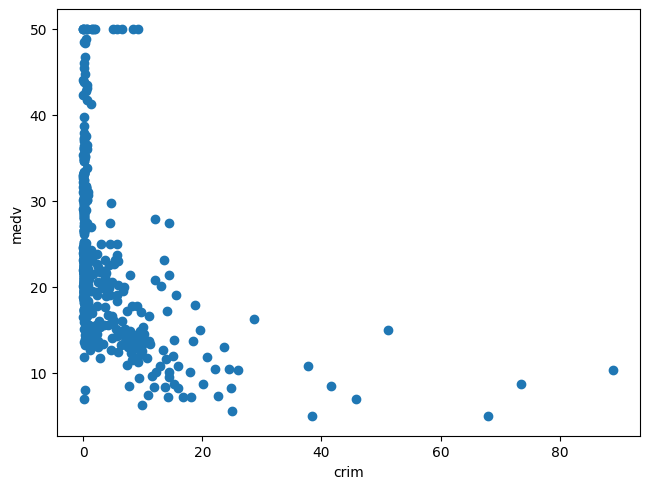

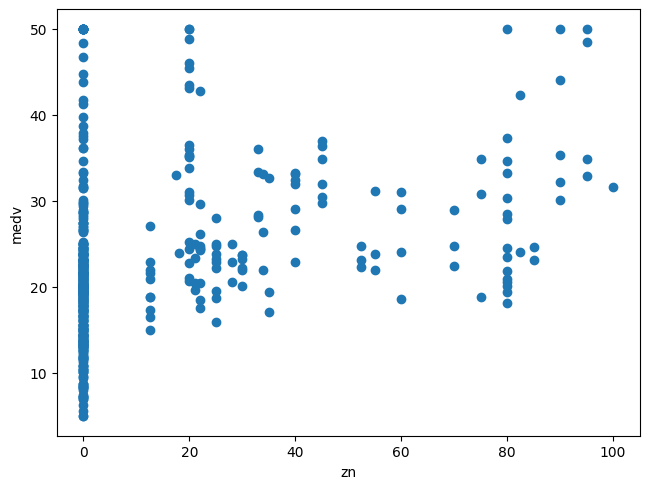

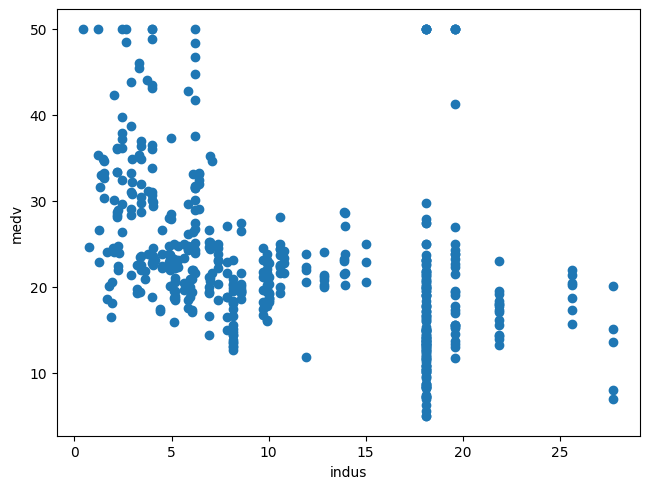

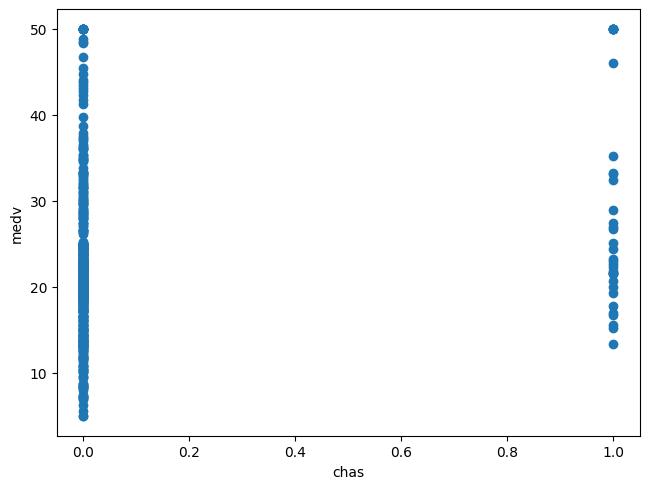

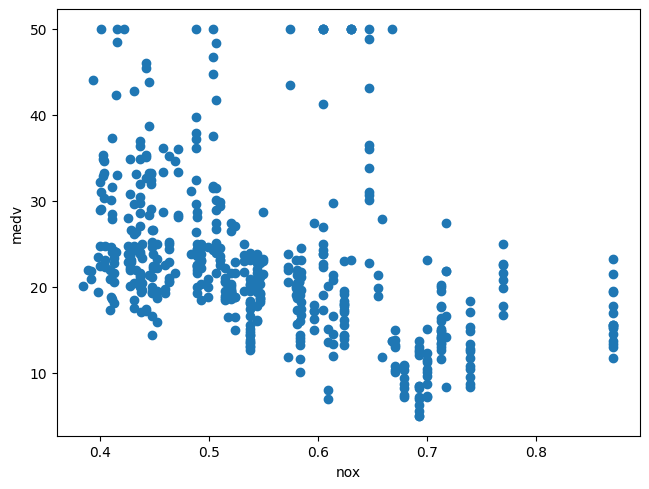

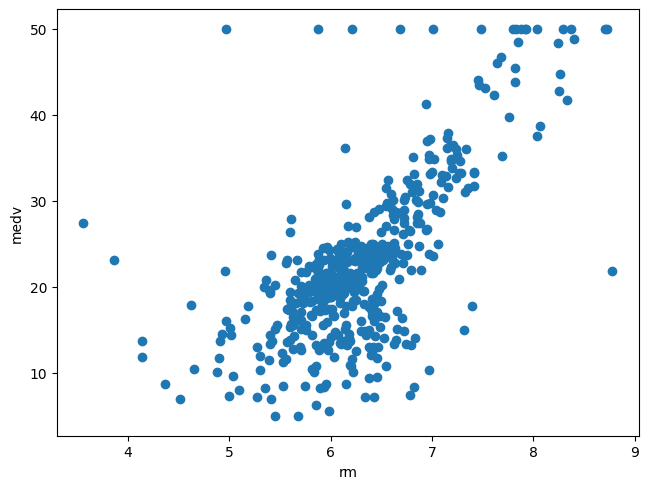

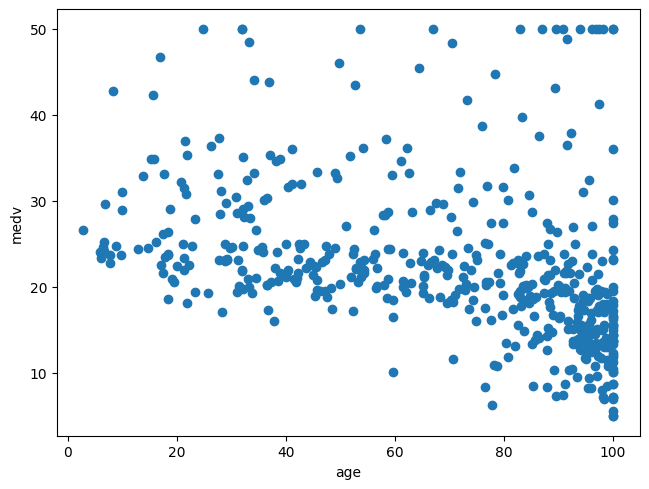

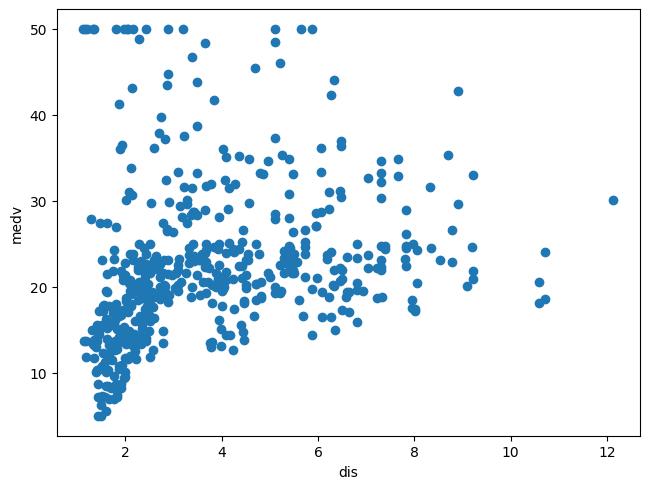

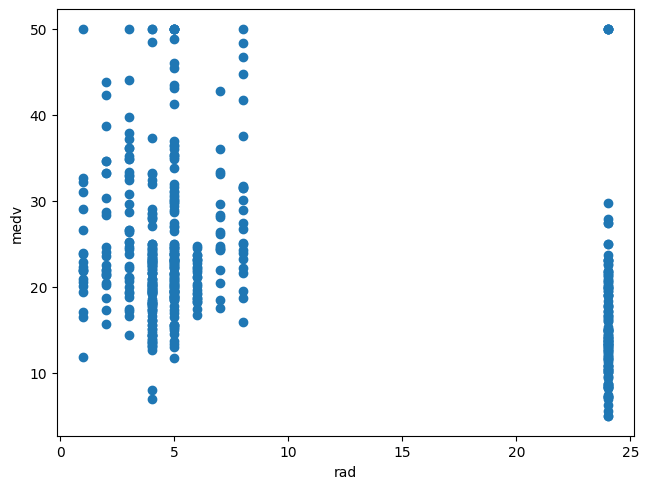

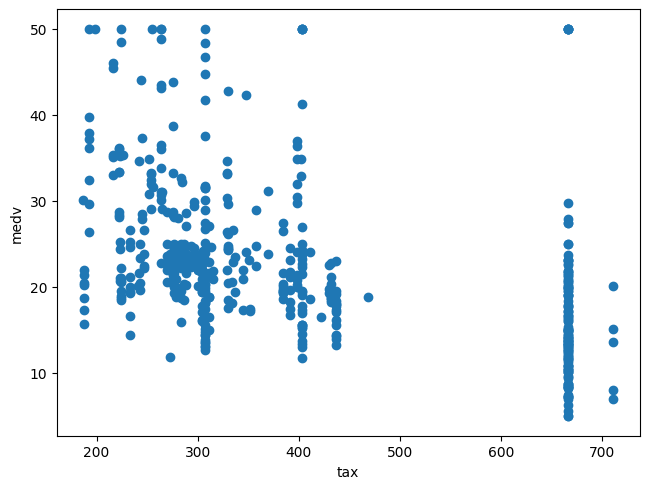

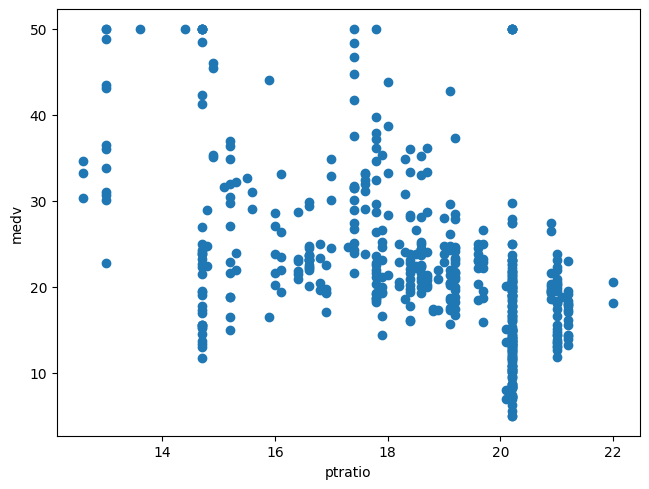

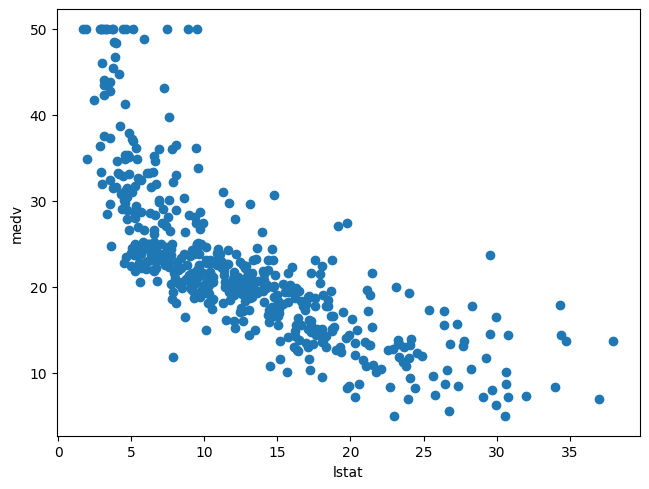

In [182]:
# Diagrama de dispersión.
for column in df_data.columns:
  if column != 'medv': # Dejando la variable medv (objetivo) fuera.
      plt.scatter(df_data[column], df_data['medv'])  # Separando las variables predictoras de la varibale objetivo (medv).
      plt.tight_layout()
      plt.xlabel(column)
      plt.ylabel('medv')
      plt.show()

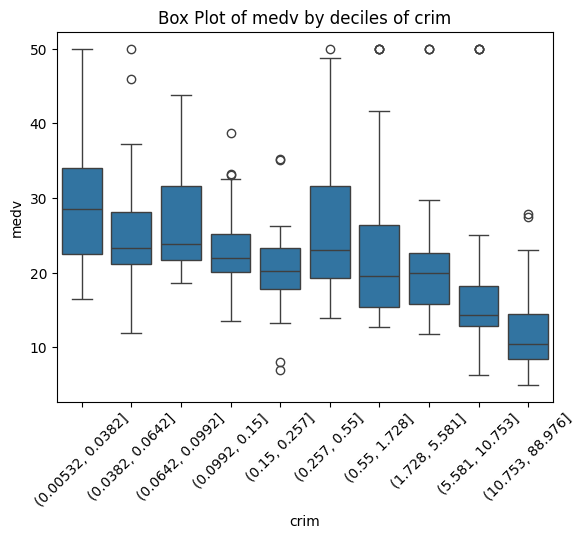

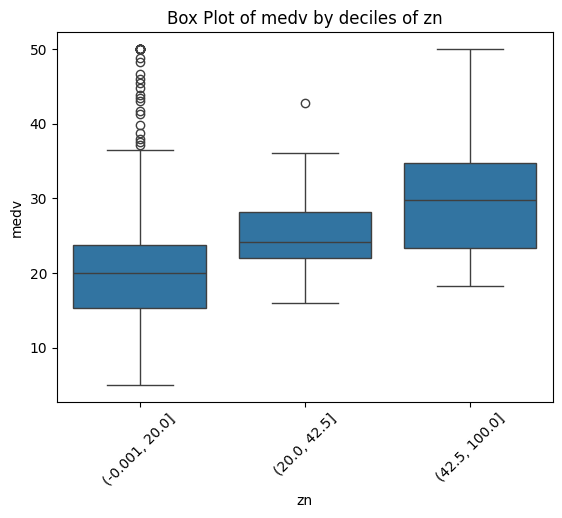

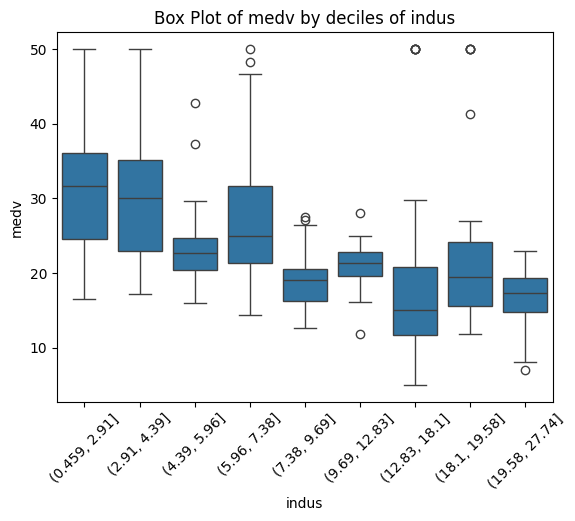

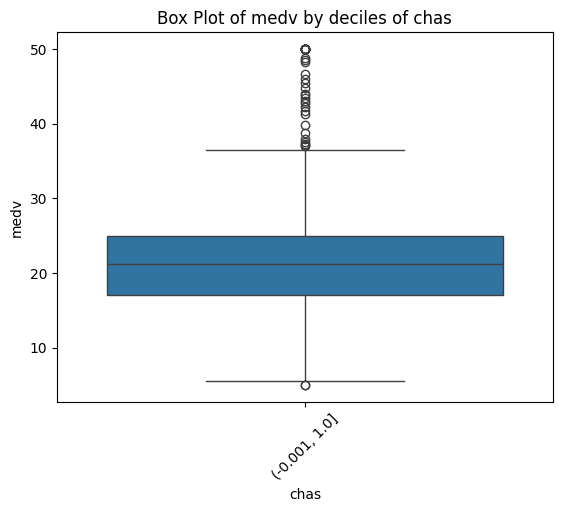

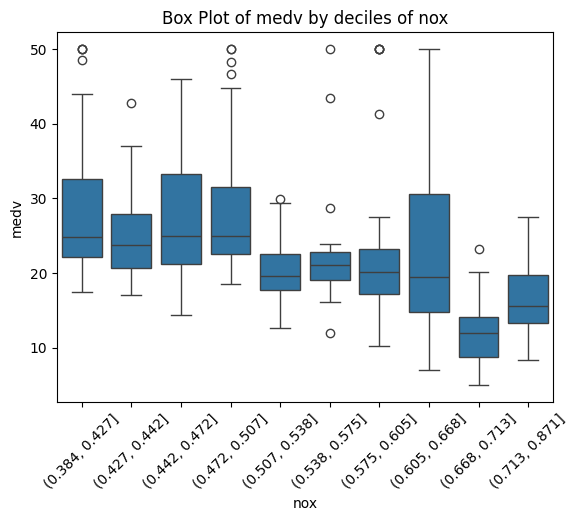

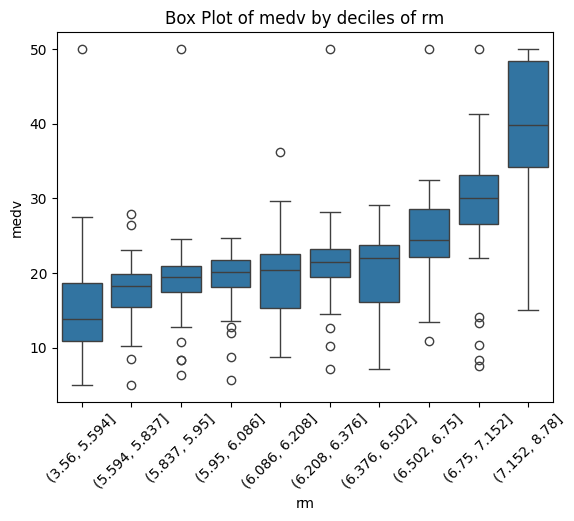

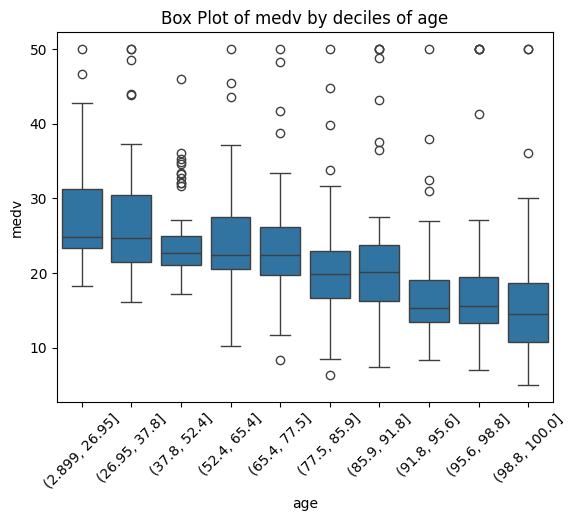

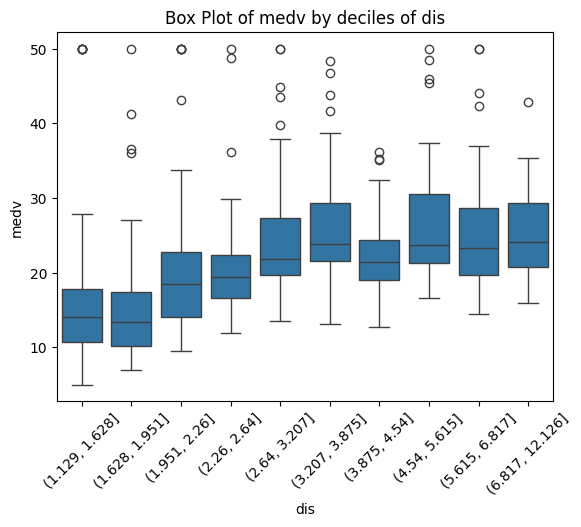

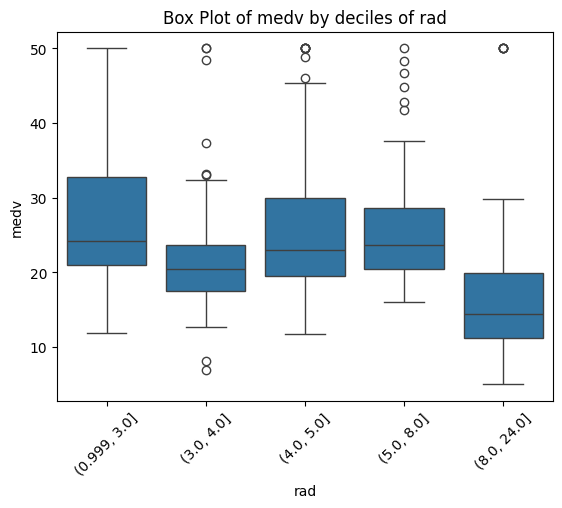

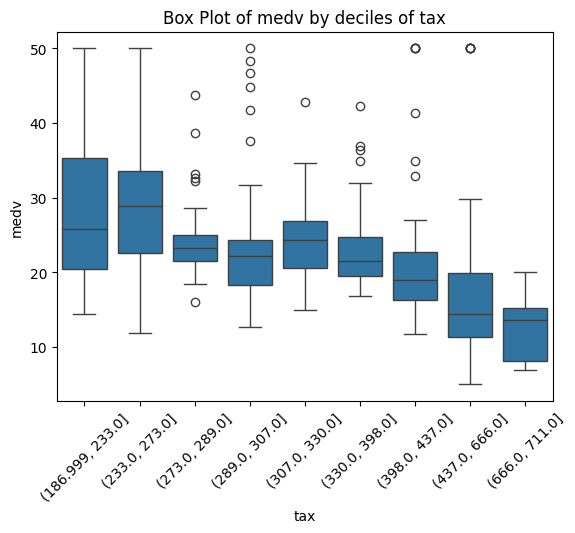

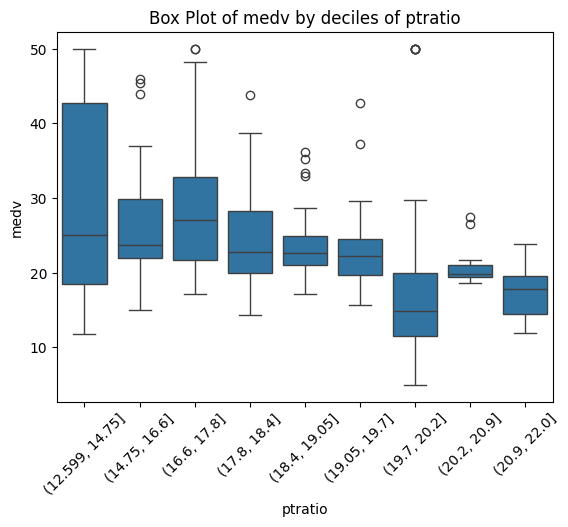

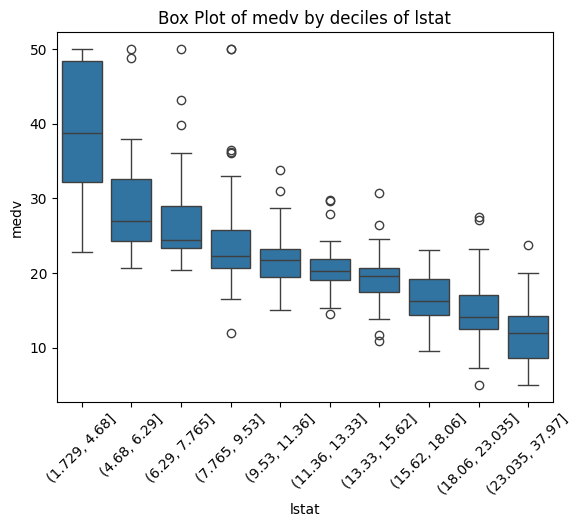

In [183]:
# Diagrama de caja agrupado por intervalos.
for column in df_data.columns:
  if column != 'medv': # Dejando la variable medv (objetivo) fuera.
      df_data['binned'] = pd.qcut(df_data[column], q=10, duplicates='drop') # Agrupando variables y nos aseguramos de borrar valores duplicados. (q=10, especificación por 'deciles')
      sns.boxplot(x='binned', y='medv', data=df_data)
      plt.xticks(rotation=45)
      plt.xlabel(column)
      plt.ylabel('medv')
      plt.title(f'Box Plot of medv by deciles of {column}')
      plt.show()
      df_data.drop('binned', axis=1, inplace=True) # Eliminando la columna binned.

In [184]:
# Preparando los datos para la Regresion Lineal Simple
A = df_data[['lstat']].values
B = df_data['medv'].values

In [185]:
# Obtenemos la media de X
A.mean()

np.float64(12.653063241106722)

In [186]:
# Obtenemos la desviación standard de X
A.std()

np.float64(7.134001636650485)

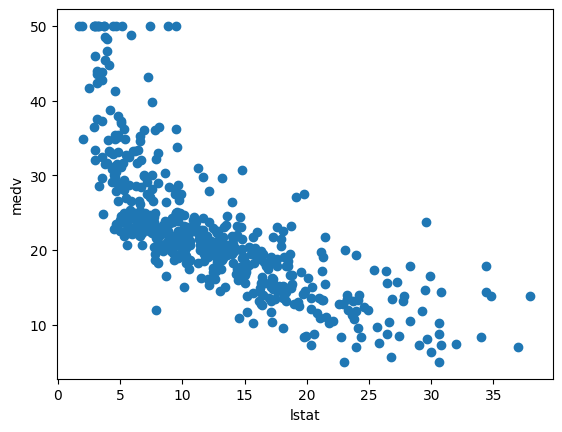

In [187]:
# Grafica de scatter.
plt.scatter(A, B)
plt.xlabel('lstat')
plt.ylabel('medv')
plt.show()

In [188]:
# Calculo de coeficientes de regresión.
Media_A = A.mean()
Media_B = B.mean()

In [189]:
# Visualizar valor de media de X.
Media_A

np.float64(12.653063241106722)

In [190]:
# Visualizar valor de media de Y.
Media_B

np.float64(22.532806324110677)

In [191]:
# Validando los valores del arreglo A.
A

array([[ 4.98],
       [ 9.14],
       [ 4.03],
       [ 2.94],
       [ 5.33],
       [ 5.21],
       [12.43],
       [19.15],
       [29.93],
       [17.1 ],
       [20.45],
       [13.27],
       [15.71],
       [ 8.26],
       [10.26],
       [ 8.47],
       [ 6.58],
       [14.67],
       [11.69],
       [11.28],
       [21.02],
       [13.83],
       [18.72],
       [19.88],
       [16.3 ],
       [16.51],
       [14.81],
       [17.28],
       [12.8 ],
       [11.98],
       [22.6 ],
       [13.04],
       [27.71],
       [18.35],
       [20.34],
       [ 9.68],
       [11.41],
       [ 8.77],
       [10.13],
       [ 4.32],
       [ 1.98],
       [ 4.84],
       [ 5.81],
       [ 7.44],
       [ 9.55],
       [10.21],
       [14.15],
       [18.8 ],
       [30.81],
       [16.2 ],
       [13.45],
       [ 9.43],
       [ 5.28],
       [ 8.43],
       [14.8 ],
       [ 4.81],
       [ 5.77],
       [ 3.95],
       [ 6.86],
       [ 9.22],
       [13.15],
       [14.44],
       [

In [192]:
# Validando los valores del arreglo B.
B

array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
       18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
       15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
       13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
       21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
       35.4, 24.7, 31.6, 23.3, 19.6, 18.7, 16. , 22.2, 25. , 33. , 23.5,
       19.4, 22. , 17.4, 20.9, 24.2, 21.7, 22.8, 23.4, 24.1, 21.4, 20. ,
       20.8, 21.2, 20.3, 28. , 23.9, 24.8, 22.9, 23.9, 26.6, 22.5, 22.2,
       23.6, 28.7, 22.6, 22. , 22.9, 25. , 20.6, 28.4, 21.4, 38.7, 43.8,
       33.2, 27.5, 26.5, 18.6, 19.3, 20.1, 19.5, 19.5, 20.4, 19.8, 19.4,
       21.7, 22.8, 18.8, 18.7, 18.5, 18.3, 21.2, 19.2, 20.4, 19.3, 22. ,
       20.3, 20.5, 17.3, 18.8, 21.4, 15.7, 16.2, 18. , 14.3, 19.2, 19.6,
       23. , 18.4, 15.6, 18.1, 17.4, 17.1, 13.3, 17.8, 14. , 14.4, 13.4,
       15.6, 11.8, 13.8, 15.6, 14.6, 17.8, 15.4, 21

In [193]:
# Imprimir lista de ambos contenedore A y B, realizando ZIP.
list(zip(A, B))

[(array([4.98]), np.float64(24.0)),
 (array([9.14]), np.float64(21.6)),
 (array([4.03]), np.float64(34.7)),
 (array([2.94]), np.float64(33.4)),
 (array([5.33]), np.float64(36.2)),
 (array([5.21]), np.float64(28.7)),
 (array([12.43]), np.float64(22.9)),
 (array([19.15]), np.float64(27.1)),
 (array([29.93]), np.float64(16.5)),
 (array([17.1]), np.float64(18.9)),
 (array([20.45]), np.float64(15.0)),
 (array([13.27]), np.float64(18.9)),
 (array([15.71]), np.float64(21.7)),
 (array([8.26]), np.float64(20.4)),
 (array([10.26]), np.float64(18.2)),
 (array([8.47]), np.float64(19.9)),
 (array([6.58]), np.float64(23.1)),
 (array([14.67]), np.float64(17.5)),
 (array([11.69]), np.float64(20.2)),
 (array([11.28]), np.float64(18.2)),
 (array([21.02]), np.float64(13.6)),
 (array([13.83]), np.float64(19.6)),
 (array([18.72]), np.float64(15.2)),
 (array([19.88]), np.float64(14.5)),
 (array([16.3]), np.float64(15.6)),
 (array([16.51]), np.float64(13.9)),
 (array([14.81]), np.float64(16.6)),
 (array([17.

In [194]:
# Insumos para calcular Beta (ß)
num = sum([(x - Media_A) * (y - Media_B) for (x, y) in list(zip(A, B))])
den = sum([(x - Media_A)**2 for x in A])

In [195]:
# Calculando beta_1
beta_1 = num / den
beta_1

array([-0.95004935])

In [196]:
# Calculando beta_0
beta_0 = Media_B - (beta_1 * Media_A)
beta_0

array([34.55384088])

In [197]:
# Calculando B_pred
B_pred = beta_0 + (beta_1 * A)
B_pred

array([[29.8225951 ],
       [25.87038979],
       [30.72514198],
       [31.76069578],
       [29.49007782],
       [29.60408375],
       [22.74472741],
       [16.36039575],
       [ 6.11886372],
       [18.30799693],
       [15.1253316 ],
       [21.94668596],
       [19.62856553],
       [26.70643322],
       [24.80633451],
       [26.50692285],
       [28.30251613],
       [20.61661686],
       [23.44776393],
       [23.83728417],
       [14.58380346],
       [21.41465832],
       [16.76891698],
       [15.66685973],
       [19.06803641],
       [18.86852605],
       [20.48360995],
       [18.13698805],
       [22.39320915],
       [23.17224962],
       [13.08272548],
       [22.16519731],
       [ 8.22797329],
       [17.12043524],
       [15.22983702],
       [25.35736314],
       [23.71377775],
       [26.22190805],
       [24.92984093],
       [30.44962767],
       [32.67274316],
       [29.95560201],
       [29.03405413],
       [27.48547369],
       [25.48086955],
       [24

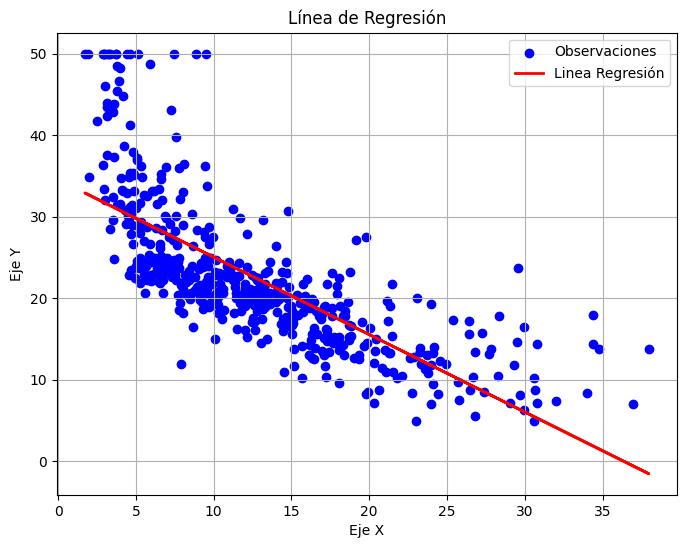

In [198]:
# Graficar Linea de Regresión
plt.figure(figsize=(8, 6))
plt.scatter(A, B, color='blue', marker = 'o', label='Observaciones')
plt.plot(A, B_pred, color='red', linewidth = 2, label='Linea Regresión') # Línea de regresión
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Línea de Regresión')
plt.legend()
plt.grid(True)

# Muestra el gráfico
plt.show()

**Según el gráfico, se refuerza la teoría que si la población es de bajo status, tiene acceso a viviendas de menor costo, podemos inferir por "el bajo poder adquisitivo", por el contrario si el indice de la población de bajo status se aproxima cero, ese segmento de población tendrá acceso a viviendas con un costo más alto y por ende, de mejor calidad**

**Creando el modelo de regresión lineal**

In [199]:
# Particionando datos para training y test del modelo.
x_train, x_test, y_train, y_test = train_test_split(A, B, test_size=0.3)

In [200]:
# Creando el modelo Linear Regression y enviando los conjuntos de datos de training.
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [201]:
# Creando la predicción del modelo para la variable objetivo 'medv'
y_predict=model.predict(x_test)
y_predict

array([25.19547068, 21.13494655, 17.06555666, 17.65069769,  6.54188387,
       18.05852325, 18.40428841, 28.661988  , 19.28199995, 18.51067769,
       14.92003954, 27.06614882, 19.87600676, 30.77204202, 23.71488655,
       24.53053769, 18.48408037, 29.83227006, 23.80354429, 25.97565872,
       21.2502016 , 18.50181191, 23.51097377, 25.43484655, 29.55743109,
       29.63722305, 24.42414841, 11.13435439, 29.50423645, 12.96956944,
       31.4724381 , 16.54247604, 13.62563665, 28.62652491, 12.24257604,
       27.44737707,  6.34683686, 10.21231397,  6.50642078, 22.78398037,
       25.08021563, 30.53266614, 24.90290016, 29.92979357, 21.16154387,
       27.81973954, 26.33915542, 29.6194915 , 19.45044965, 18.42201995,
       29.67268614, 22.98789315, 30.90502862, 27.51830326, 26.56079975,
       24.27343027, 20.21290614, 10.04386428,  6.51528655, 21.94173191,
       31.11780717, 23.54643686, 26.92429645, 29.49537068, 21.88853728,
       30.86069975, 29.20280016, 15.65589872, 25.11567872, 20.72

In [202]:
# Creando un nuevo dataframe con el valor actual de 'medv' y el valor y_predict de 'medv'
df_actualpredict = pd.DataFrame({"Actual":y_test,"Predict":y_predict})
df_actualpredict

,Actual,Predict
0,21.2,25.195471
1,19.9,21.134947
2,15.2,17.065557
3,22.5,17.650698
4,5.0,6.541884
...,...,...
147,13.9,13.058227
148,17.8,17.296067
149,21.0,23.041088
150,8.3,16.134650


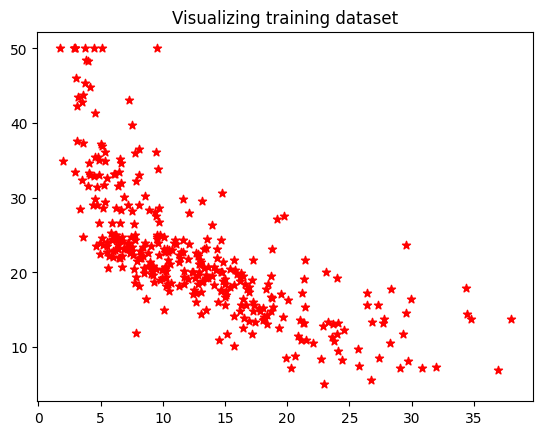

In [203]:
# Visualizar el grafico para el modelo entrenado.
plt.scatter(x_train,y_train,color="r",marker="*")
plt.title("Visualizing training dataset")
plt.show()

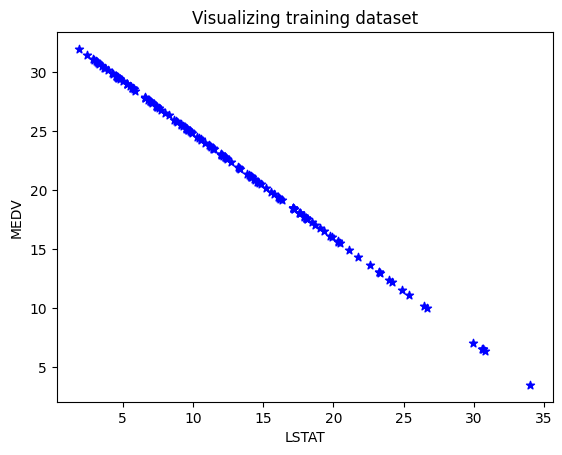

In [204]:
# Visualizando el grafico para la predicción del modelo .
# Como la predicción del modelo se realizó utilizando los datos del dataframe x-test, la grafica se debe generar respetando los dfs utilizados para la predicción.
plt.scatter(x_test,y_predict,color="b",marker="*")
plt.title("Visualizing training dataset")
plt.xlabel("LSTAT")
plt.ylabel("MEDV")
plt.show()

In [205]:
# Revisando el score trained del modelo.
model.score(x_train,y_train)*100

51.99953386873561

In [206]:
# Revisando el score tested del modelo.
model.score(x_test,y_test)*100

58.09946058533724

In [207]:
# Calcular el R2 score.
from sklearn.metrics import r2_score
r2_score(y_test,y_predict)*100

58.09946058533724

In [208]:
# Calculando el mean squared error.
mean_squared_error(y_test,y_predict)

41.68424891725525

In [209]:
# Calculando el RMSE
np.sqrt(mean_squared_error(y_test,y_predict))

np.float64(6.456334015310488)

In [210]:
# Calculando el error porcentual relativo de la predicción.
# Calcular RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_predict))

# Calcular el promedio de los precios reales
mean_price = np.mean(y_test)

# Error porcentual relativo
relative_error = (rmse / mean_price) * 100

print("RMSE:", rmse)
print("Error porcentual relativo:", relative_error, "%")

RMSE: 6.456334015310488
Error porcentual relativo: 28.499819083672946 %


In [211]:
# Revisando el score de predicción del modelo,
model.score(x_test, y_predict)*100

100.0

In [212]:
r2_score(y_test,y_predict)

0.5809946058533724

In [213]:
# Coeficiente de regresión
cr = model.coef_
cr

array([-0.88657732])

In [214]:
# Coeficiente intercept
ci = model.intercept_
ci

np.float64(33.66228408264374)

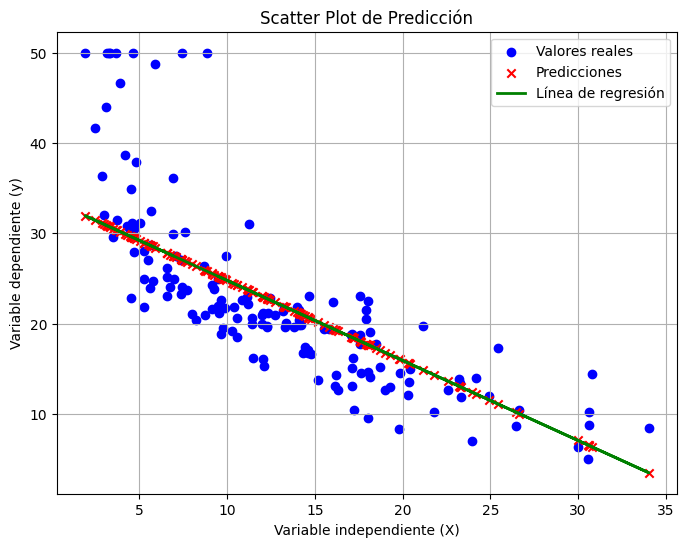

In [215]:
# Scatter plot: valores reales vs predichos
plt.figure(figsize=(8,6))
plt.scatter(x_test, y_test, color="blue", label="Valores reales")
plt.scatter(x_test, y_predict, color="red", marker="x", label="Predicciones")
plt.plot(x_test, y_predict, color="green", linewidth=2, label="Línea de regresión")

# Personalización
plt.title("Scatter Plot de Predicción")
plt.xlabel("Variable independiente (X)")
plt.ylabel("Variable dependiente (y)")
plt.legend()
plt.grid(True)
plt.show()

**Regresión Múltiple**

In [216]:
# Realizando un nuevo particionamiento de datos.
# Primero particionamos 30% para pruebas y el restante 70% es para training.
train, test = train_test_split(df_data, test_size=0.3, random_state=42)
# Del 30% particionado en el paso anterior, realizamos el particionamiento del 50% para pruebas, por lo tanto, el restante 50% es para validación.
# De esta manera asignamos el 50% de 30% = 15% global para cada set.
test, val = train_test_split(test, test_size=0.5)

In [217]:
# Generando el escalamiento standard.
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train)
train_scaled = pd.DataFrame(train_scaled, columns=train.columns)

In [239]:
# Asignando valores a variables X training y X test para modelo de regresion lineal
x_train1 = train[['crim','zn','indus','chas','nox','rm','age','dis','rad','tax','ptratio','lstat']]
x_test1 = test[['crim','zn','indus','chas','nox','rm','age','dis','rad','tax','ptratio','lstat']]

In [240]:
# Asignando valores a variables Y training y Y test para modelo de regresion lineal
y_train1 = train['medv']
y_test1 = test['medv']

In [246]:
# Calculando la regresión lineal.
linearReg = LinearRegression()
linearReg.fit(x_train1, y_train1)

# Calculando Train R^2
trainR2 = linearReg.score(x_train1, y_train1)
# Calculando Test R^2
testR2 = linearReg.score(x_test1, y_test1)
print(f"Train R^2: ", trainR2)
print(f"Test R^2: ", testR2)
#

# Calculando prediccion de Y para training
train['y_predicted'] = linearReg.predict(x_train1)
# Calculando prediccion de Y para test
test['y_predicted'] = linearReg.predict(x_test1)
print(f"Train MSE, {mean_squared_error(y_train1, train['y_predicted'])}")
print(f"Test MSE, {mean_squared_error(y_test1, test['y_predicted'])}")

predictedR2 = linearReg.score(x_test1, test['y_predicted'])
print(f"Predicted R^2: ", predictedR2)
test

Train R^2:  0.7340777261931662
Test R^2:  0.737964080176627
Train MSE, 23.373644961405006
Test MSE, 20.45137865378069
Predicted R^2:  1.0


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv,y_predicted
274,0.05644,40.0,6.41,1,0.447,6.758,32.9,4.0776,4,254,17.6,3.53,32.4,36.815495
68,0.13554,12.5,6.07,0,0.409,5.594,36.8,6.4980,4,345,18.9,13.09,17.4,17.527487
491,0.10574,0.0,27.74,0,0.609,5.983,98.8,1.8681,4,711,20.1,18.07,13.6,14.773427
86,0.05188,0.0,4.49,0,0.449,6.015,45.1,4.4272,3,247,18.5,12.86,22.5,22.004579
101,0.11432,0.0,8.56,0,0.520,6.781,71.3,2.8561,5,384,20.9,7.67,26.5,25.964418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,0.13960,0.0,8.56,0,0.520,6.167,90.0,2.4210,5,384,20.9,12.33,20.1,21.331503
355,0.10659,80.0,1.91,0,0.413,5.936,19.5,10.5857,4,334,22.0,5.57,20.6,17.220246
24,0.75026,0.0,8.14,0,0.538,5.924,94.1,4.3996,4,307,21.0,16.30,15.6,15.333921
485,3.67367,0.0,18.10,0,0.583,6.312,51.9,3.9917,24,666,20.2,10.58,21.2,22.108730


/tmp/ipython-input-316066549.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


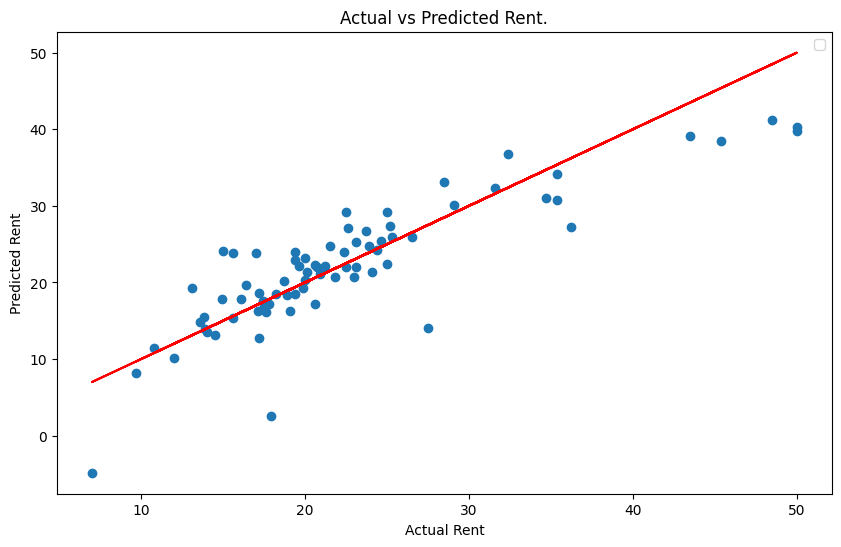

In [248]:
# 9.2 Plot of the OLS Line
plt.figure(figsize=(10, 6))
plt.scatter(test['medv'], test['y_predicted'])
plt.plot(test['medv'], test['medv'], color='red')
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Actual vs Predicted Rent.')
plt.legend()
plt.show()

**Creando modelo que use lstat, age y su interacción como predictores**

In [259]:
# Crear nuevo dataframe con las tres variables necesarias.
#df_data_lstat_age = df_data[['lstat', 'age', 'medv']]
df_data['lstat_age'] = df_data['lstat'] * df_data['age']
df_data

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv,lstat_age
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,324.696
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,721.146
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,246.233
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,134.652
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,288.886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4,668.197
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6,696.436
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9,513.240
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0,578.664


In [260]:
# Particionando dataframe para modelo de interacción.
X_interact = df_data[['lstat', 'age', 'lstat_age']]
Y_interact = df_data['medv']

In [261]:
# Creando modelo de interacción.
model_interact = LinearRegression()
model_interact.fit(X_interact, Y_interact)

LinearRegression()

In [262]:
# Mostrar coeficientes.
coef_names = X_interact.columns
for name, coef in zip(coef_names, model_interact.coef_):
  print(f"{name}: {coef:.4f}")

lstat: -1.3921
age: -0.0007
lstat_age: 0.0042


In [264]:
# Agregando lstst2 y log(rm) al dataframe df_data_lstat_age.
df_data['lstat2'] = np.square(df_data['lstat'])
df_data['logrm'] = np.log(df_data['rm'])
df_data

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv,lstat_age,lstat2,logrm
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,324.696,24.8004,1.883275
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,721.146,83.5396,1.859574
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,246.233,16.2409,1.971996
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,134.652,8.6436,1.945624
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,288.886,28.4089,1.966693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4,668.197,93.5089,1.886008
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6,696.436,82.4464,1.811562
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9,513.240,31.8096,1.942476
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0,578.664,41.9904,1.916040


In [266]:
# Realizando la validación cruzada.
from sklearn.model_selection import cross_val_score

X_trans = df_data[['lstat', 'age', 'lstat2', 'logrm']]
Y_trans = df_data['medv']

model_trans = LinearRegression()
scores = cross_val_score(model_trans, X_trans, Y_trans, cv=5, scoring='r2')
print(scores)
#

[ 0.58929096  0.78445439  0.45062859  0.35329023 -0.05388991]


In [268]:
# Analizar Overfitting
# Primero particionamos 10% para training y el restante 90% es para testing.
train, test = train_test_split(df_data, test_size=0.9, random_state=42)

# Asignando valores a variables X training y X test para modelo de regresion lineal
x_train2 = train[['crim','zn','indus','chas','nox','rm','age','dis','rad','tax','ptratio','lstat','lstat_age','lstat2','logrm']]
x_test2 = test[['crim','zn','indus','chas','nox','rm','age','dis','rad','tax','ptratio','lstat','lstat_age','lstat2','logrm']]

# Asignando valores a variables Y training y Y test para modelo de regresion lineal
y_train2 = train['medv']
y_test2 = test['medv']

# Calculando la regresión lineal.
linearRegr = LinearRegression()
linearRegr.fit(x_train2, y_train2)

# Calculando Train R^2
trainR2 = linearRegr.score(x_train2, y_train2)
# Calculando Test R^2
testR2 = linearRegr.score(x_test2, y_test2)
print(f"Train R^2: ", trainR2)
print(f"Test R^2: ", testR2)
#

# Calculando prediccion de Y para training
train['y_predicted'] = linearRegr.predict(x_train2)
# Calculando prediccion de Y para test
test['y_predicted'] = linearRegr.predict(x_test2)
print(f"Train MSE, {mean_squared_error(y_train2, train['y_predicted'])}")
print(f"Test MSE, {mean_squared_error(y_test2, test['y_predicted'])}")

predictedR2 = linearRegr.score(x_test2, test['y_predicted'])
print(f"Predicted R^2: ", predictedR2)
test

Train R^2:  0.7795761655116413
Test R^2:  0.522595792456531
Train MSE, 14.62907494019798
Test MSE, 41.24716286834254
Predicted R^2:  1.0


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv,lstat_age,lstat2,logrm,y_predicted
173,0.09178,0.0,4.05,0,0.510,6.416,84.1,2.6463,5,296,16.6,9.04,23.6,760.264,81.7216,1.858795,23.483487
274,0.05644,40.0,6.41,1,0.447,6.758,32.9,4.0776,4,254,17.6,3.53,32.4,116.137,12.4609,1.910727,36.185922
491,0.10574,0.0,27.74,0,0.609,5.983,98.8,1.8681,4,711,20.1,18.07,13.6,1785.316,326.5249,1.788922,16.712637
72,0.09164,0.0,10.81,0,0.413,6.065,7.8,5.2873,4,305,19.2,5.52,22.8,43.056,30.4704,1.802535,26.218422
452,5.09017,0.0,18.10,0,0.713,6.297,91.8,2.3682,24,666,20.2,17.27,16.1,1585.386,298.2529,1.840073,18.281511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.97617,0.0,21.89,0,0.624,5.757,98.4,2.3460,4,437,21.2,17.31,15.6,1703.304,299.6361,1.750417,15.191529
306,0.07503,33.0,2.18,0,0.472,7.420,71.9,3.0992,7,222,18.4,6.47,33.4,465.193,41.8609,2.004179,33.084036
486,5.69175,0.0,18.10,0,0.583,6.114,79.8,3.5459,24,666,20.2,14.98,19.1,1195.404,224.4004,1.810581,22.068855
319,0.47547,0.0,9.90,0,0.544,6.113,58.8,4.0019,4,304,18.4,12.73,21.0,748.524,162.0529,1.810418,18.804912


In [278]:
# Aplicando Modelo Ridge
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)  # alpha controla la penalización
ridge.fit(x_train2, y_train2)

# Prediccion
y_pred_ridge_test  = ridge.predict(x_test2)
y_pred_ridge_train = ridge.predict(x_train2)

# Evaluación
print("Ridge R2 test:", r2_score(y_test2, y_pred_ridge_test))
print("Ridge R2 train:", r2_score(y_train2, y_pred_ridge_train))

# Coeficiente Ridge
print("Coeficientes Ridge:", ridge.coef_)

Ridge R2 test: 0.7071896766139943
Ridge R2 train: 0.7005854107799373
Coeficientes Ridge: [ 0.0345741   0.04584928 -0.21530906  5.30051679 -1.43702514  3.26589262
  0.02735975 -1.14589695  0.35753553 -0.01345595 -0.73960596 -0.49695033
 -0.00578768  0.01531605 -0.04977797]


In [286]:
# Aplicando Modelo Lasso
from sklearn.linear_model import Lasso

# Modelo Lasso
lasso = Lasso(alpha=1.0)  # alpha controla la penalización
lasso.fit(x_train2, y_train2)

# Predicción
y_pred_lasso_test = lasso.predict(x_test2)
y_pred_lasso_train = lasso.predict(x_train2)

# Evaluación
print("Lasso R2 test:", r2_score(y_test2, y_pred_lasso_test))
print("Lasso R2 train:", r2_score(y_train2, y_pred_lasso_train))

# Coeficiente Lasso.
print("Coeficientes Lasso:", lasso.coef_)

Lasso R2 test: 0.6536844804955371
Lasso R2 train: 0.6069756512466595
Coeficientes Lasso: [ 0.          0.05024885 -0.15416267  0.         -0.          0.
  0.13640481 -0.13580532  0.37456149 -0.009578   -0.80948913 -0.62690149
 -0.01014524  0.02144432  0.        ]


**El modelo que mejor nos ayuda a luchar contra sobreajuste en este caso, es el modelo Ridge con alpha=1.0, ya que los resultados de R2 son más aproximados, lo que nos dará una evaluación del modelo más aceptable**